## <span style=color:blue>Imports/Packages</span>

In [40]:
#pip install kagglehub

In [41]:
#Basics:
import pandas as pd
import numpy as np

#Plotting:
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9

#Scraping:
import kagglehub
import os

### <span style=color:green>Scrapping from Kaggle: </span>

In [42]:
#Pulling directly from Kaggle itself: 
path = kagglehub.dataset_download("mysarahmadbhat/airbnb-listings-reviews")
print(os.listdir(path))

['Airbnb Data']


In [43]:
#Path/foldername:
folder = os.path.join(path, 'Airbnb Data')

#Each file: 
listings_path =os.path.join(folder, "Listings.csv")
listing_dict_path = os.path.join(folder, "Reviews_data_dictionary.csv")
review_path = os.path.join(folder, "Reviews.csv")
review_dict_path = os.path.join(folder, "Listings_data_dictionary.csv")

In [44]:
listing_df = pd.read_csv(listings_path, encoding="latin1", low_memory = False) #'utf-8' codec error. Named old_ because data cleaning is necessary.
listing_dict = pd.read_csv(listing_dict_path, low_memory = False)
review_df = pd.read_csv(review_path, low_memory = False)
review_dict= pd.read_csv(review_dict_path, low_memory = False)

### <span style=color:green>Alternatively: </span>

In [45]:
#Importing the Data:
#listing_df = pd.read_csv("Airbnb Data\Listings.csv",encoding="latin1") #'utf-8' codec error. Named old_ because data cleaning is necessary.
#listing_dict = pd.read_csv("Airbnb Data\Reviews_data_dictionary.csv")
#review_df = pd.read_csv("Airbnb Data\Reviews.csv")
#review_dict = pd.read_csv("Airbnb Data\Listings_data_dictionary.csv")

### <span style=color:green>Inspecting Datasets </span>

In [46]:
review_dict

,Field,Description
0,listing_id,Listing ID
1,name,Listing Name
2,host_id,Host ID
3,host_since,Date the Host joined Airbnb
4,host_location,Location where the Host is based
5,host_response_time,Estimate of how long the Host takes to respond
6,host_response_rate,Percentage of times the Host responds
7,host_acceptance_rate,Percentage of times the Host accepts a booking...
8,host_is_superhost,Binary field to determine if the Host is a Sup...
9,host_total_listings_count,Total listings the Host has in Airbnb


In [47]:
listing_df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [48]:
listing_dict.head()

,Field,Description
0,listing_id,Listing ID
1,review_id,Review ID
2,date,Review date
3,reviewer_id,Reviewer ID


In [49]:
review_df.head()

,listing_id,review_id,date,reviewer_id
0,11798,330265172,2018-09-30,11863072
1,15383,330103585,2018-09-30,39147453
2,16455,329985788,2018-09-30,1125378
3,17919,330016899,2018-09-30,172717984
4,26827,329995638,2018-09-30,17542859


### <span style=color:green>Inspecting Data Types </span>

In [50]:
listing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [51]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5373143 entries, 0 to 5373142
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   listing_id   int64 
 1   review_id    int64 
 2   date         object
 3   reviewer_id  int64 
dtypes: int64(3), object(1)
memory usage: 164.0+ MB


## <span style=color:blue>Data Cleaning</span>

In [52]:
listing_df.isna().sum()

listing_id                          0
name                              175
host_id                             0
host_since                        165
host_location                     840
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
host_is_superhost                 165
host_total_listings_count         165
host_has_profile_pic              165
host_identity_verified            165
neighbourhood                       0
district                       242700
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        29435
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating            91405
review_score

In [53]:
review_df.isna().sum()

listing_id     0
review_id      0
date           0
reviewer_id    0
dtype: int64

### <span style=color:green>Dropping Nulls </span>

#### We will be dropping nulls in the following areas:
1) host_since... (host-related entries each have 165 null values, likely tied)
2) host_location (Useful if host geospatial analysis is needed)
3) name
4) review_scores... (Allows us to perform analysis on review_score metrics)

#### We only want to drop from the following because dropping anything more (host_response.., district, bedrooms) can remove a large portion of our dataset, leading our conclusions to drastically change. 

#### Instead, we will opt to **not use** the following columns for our analysis.

In [54]:
listing_df = listing_df.dropna(subset=['host_since', 'host_location', 'name', 'review_scores_location', 'review_scores_rating', 
                                           'review_scores_accuracy', 'review_scores_value', 'review_scores_communication',
                                          'review_scores_checkin', 'review_scores_cleanliness'])


In [55]:
listing_df.isna().sum()

listing_id                          0
name                                0
host_id                             0
host_since                          0
host_location                       0
host_response_time              76690
host_response_rate              76690
host_acceptance_rate            58780
host_is_superhost                   0
host_total_listings_count           0
host_has_profile_pic                0
host_identity_verified              0
neighbourhood                       0
district                       160720
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        19690
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating                0
review_score

### <span style=color:green>Converting to Datetime </span>

#### Converting Date fields/columns into dtype datetime allows us to perform time-related analysis.

In [56]:
listing_df['host_since']  = pd.to_datetime(listing_df['host_since'])
review_df['date'] = pd.to_datetime(review_df['date'])

In [57]:
listing_df['host_since'].dtype

dtype('<M8[ns]')

In [58]:
review_df['date'].dtype

dtype('<M8[ns]')

### <span style=color:green>Converting to Bool </span>

In [59]:
tf = ['host_is_superhost', 'instant_bookable', 'host_identity_verified', 'host_has_profile_pic']

for i in tf:
    listing_df[i] = listing_df[i].map({'t': True,'f': False})

### <span style=color:green>Checking for valid values: </span>

#### Certain values should not noted as 0. This includes:
1) accommodates
2) bedrooms
3) price
4) minimum_nights
5) maximum_nights

In [60]:
(listing_df[['accommodates', 'bedrooms', 'price', 'minimum_nights', 'maximum_nights']] == 0).sum()

accommodates      0
bedrooms          0
price             0
minimum_nights    0
maximum_nights    0
dtype: int64

### <span style=color:green>Ensuring no duplicate values: </span>

In [61]:
listing_df = listing_df.drop_duplicates()
review_df = review_df.drop_duplicates()

In [62]:
listing_df['listing_id'].is_unique

True

### <span style=color:green>Filtering Review IDs: </span>

#### Only unique Review IDs, no duplicates.

In [63]:
review_df['review_id'].is_unique


False

In [64]:
review_df['review_id'].nunique()

5372983

In [65]:
len(review_df)

5373143

In [66]:
review_df = review_df.drop_duplicates(subset=['review_id'], keep='first')

In [67]:
review_df['review_id'].is_unique

True

### <span style=color:green>Uncovering outliers: </span>

In [68]:
listing_df[['price', 'minimum_nights', 'maximum_nights']].describe()

,price,minimum_nights,maximum_nights
count,187376.000000,187376.000000,1.873760e+05
mean,472.665790,7.140306,4.068246e+04
std,2113.764749,32.354250,8.898104e+06
min,8.000000,1.000000,1.000000e+00
25%,70.000000,1.000000,4.500000e+01
50%,134.000000,2.000000,1.125000e+03
75%,400.000000,4.000000,1.125000e+03
max,300177.000000,9999.000000,2.147484e+09


#### Deleting Outliers

In [69]:
columns = [
    'price',
    'minimum_nights',
    'maximum_nights'
]

for col in columns:
    q1 = listing_df[col].quantile(0.25)
    q3 = listing_df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    listing_df = listing_df[(listing_df[col] >= lower_bound) & (listing_df[col] <= upper_bound)]

In [70]:
listing_df[['price', 'minimum_nights', 'maximum_nights']].describe()

,price,minimum_nights,maximum_nights
count,139935.000000,139935.000000,139935.000000
mean,203.075692,2.382578,665.583135
std,201.053996,1.530156,523.883981
min,8.000000,1.000000,1.000000
25%,69.000000,1.000000,30.000000
50%,115.000000,2.000000,1125.000000
75%,260.000000,3.000000,1125.000000
max,895.000000,8.000000,2500.000000


In [71]:
listing_df['listing_id'].is_unique

True

In [72]:
listing_df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,False,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False


In [77]:
review_df.head()

,listing_id,review_id,date,reviewer_id
0,11798,330265172,2018-09-30,11863072
1,15383,330103585,2018-09-30,39147453
2,16455,329985788,2018-09-30,1125378
3,17919,330016899,2018-09-30,172717984
4,26827,329995638,2018-09-30,17542859


## <span style=color:blue>Exporting Data</span>

In [80]:
listing_df.to_csv("updated_listing.csv", index=False)
review_df.to_csv("updated_review.csv",index = False)

## <span style=color:blue>Exploratory Data Analysis</span>

### <span style=color:green>Distribution of top 10 neighourhoods </span>

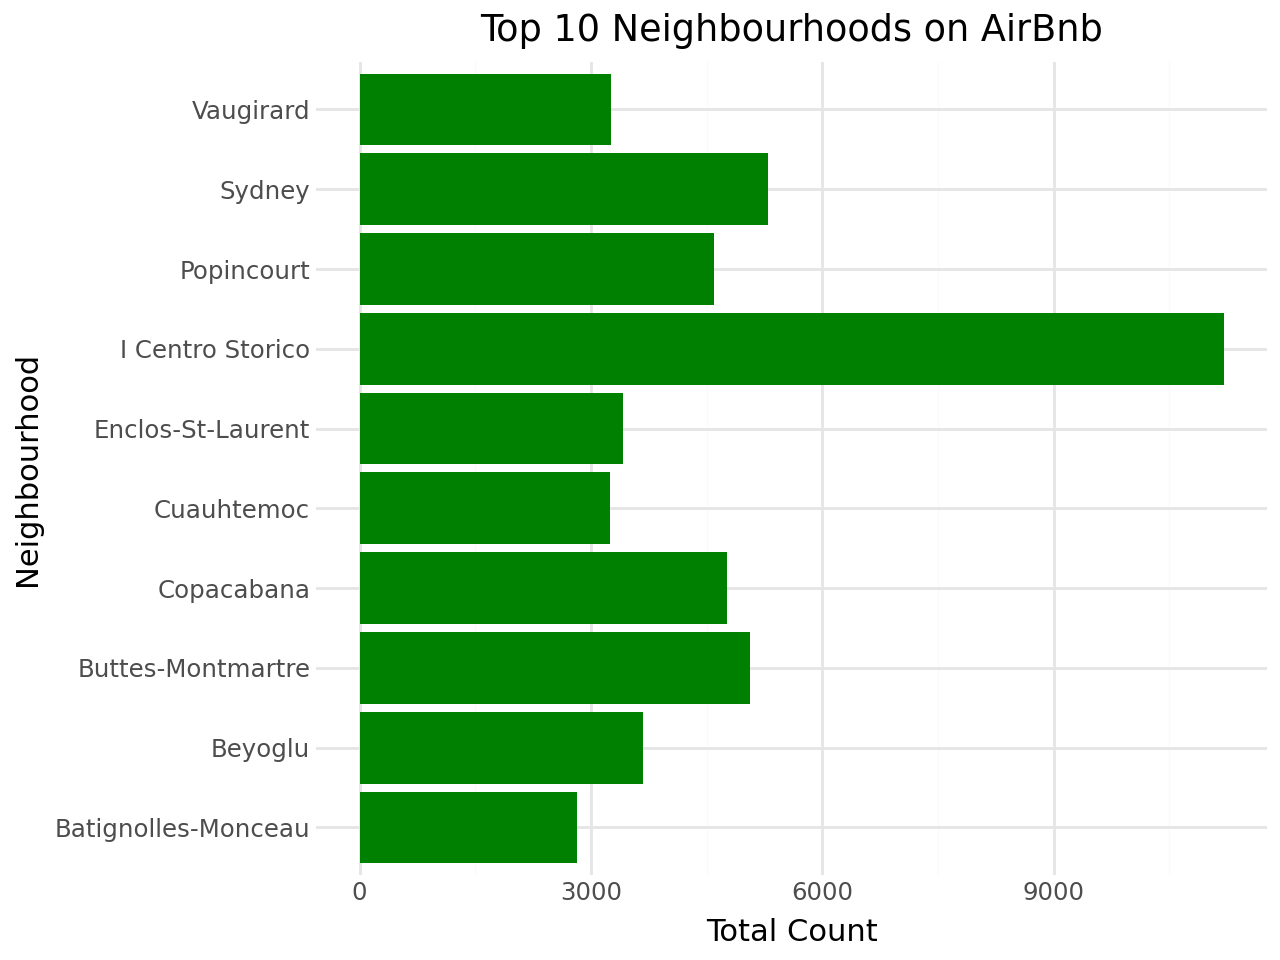

In [75]:
top_10 = listing_df['neighbourhood'].value_counts().nlargest(10).index

top10_df = listing_df[listing_df['neighbourhood'].isin(top_10)]

(
    p9.ggplot(top10_df, p9.aes(x= 'neighbourhood'))
    + p9.geom_bar(fill= "green")
    + p9.coord_flip() #Reduces col names from overlapping
    + p9.labs(title= "Top 10 Neighbourhoods on AirBnb", x = "Neighbourhood", y = "Total Count")
    + p9.theme_minimal()
)

### <span style=color:green>Heatmap of Review Scores</span>

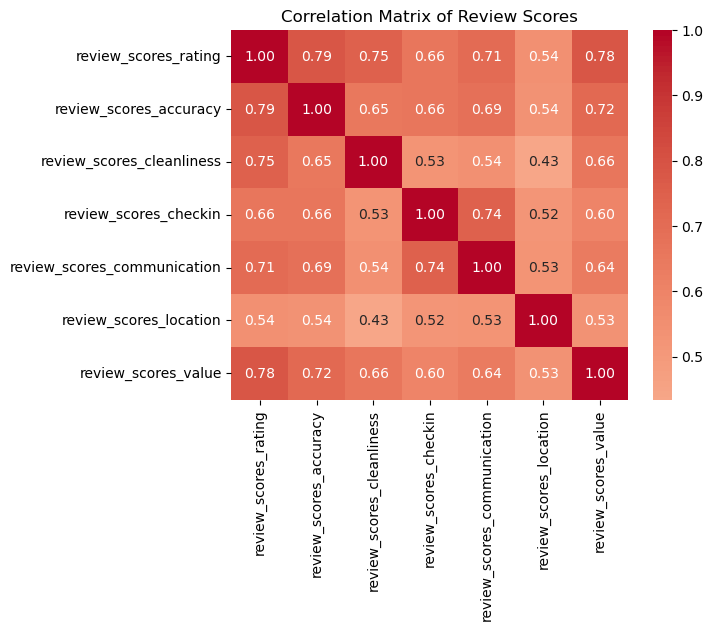

In [76]:
review_col = [col for col in listing_df.columns if 'review_scores' in col]
corr_matrix = listing_df[review_col].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center = 0)
plt.title("Correlation Matrix of Review Scores")
plt.show()